# Dataset19 — Step 1: Load data and compute CFO

**Hardware:** Silicon Labs BRD4185A (EFR32BG22), 4×4 URA of CP patch antennas, pitch 40 mm.
**Dataset19:** 7×7 tag grid, 40 cm spacing, grid plane at x = 295 cm from the array.
11 reference tags are fixed on the grid; 4 tracking tags move between grid points in each set (set1–set7, plus a short `test` recording with the reference tags only).

This notebook covers only the first two steps of the pipeline:

0. Background A/B: how I/Q samples arise and what the CFO is
1. Parse `setup.txt` → tag positions and ground-truth AZ/EL
2. Load the CTE packet CSVs
3. Estimate the per-packet carrier frequency offset (CFO) from the reference period (IQ1–IQ8)

Everything else (SFO correction of the switched slots, snapshots, MUSIC) comes later.

## Background A: from the received RF signal to I/Q samples

*For readers who have not met baseband signals before. Everything below is trigonometry.*

### 1. The received signal

The tag transmits the CTE as a pure tone. At the anchor's antenna it arrives as a cosine with amplitude $A$, frequency $f_r$ and some phase $\phi$:

$$ s_r(t) = A\cos\!\left(2\pi f_r t + \phi\right). $$

The receiver's local oscillator (LO) is tuned to the nominal channel frequency $f_o$. Because the tag's crystal and the anchor's crystal are never exactly equal, and because the CTE tone itself sits 250 kHz above the channel centre, the received frequency is not $f_o$ but $f_r = f_o + \Delta f$. Substituting:

$$ s_r(t) = A\cos\!\left(2\pi f_o t + 2\pi\,\Delta f\, t + \phi\right). $$

Everything we care about — the small offset $\Delta f$ and the phase $\phi$ — is hidden inside the argument of a cosine oscillating at 2.4 GHz. Mixing is how we pull it out.

For compactness write the slow part of the argument as

$$ \theta(t) = 2\pi\,\Delta f\, t + \phi , \qquad\text{so that}\qquad s_r(t) = A\cos\!\left(2\pi f_o t + \theta(t)\right). $$

### 2. Expand the cosine

Using $\cos(\alpha+\beta) = \cos\alpha\cos\beta - \sin\alpha\sin\beta$ with $\alpha = 2\pi f_o t$ and $\beta = \theta(t)$:

$$ s_r(t) = A\Big[\cos(2\pi f_o t)\cos\theta(t) - \sin(2\pi f_o t)\sin\theta(t)\Big]. $$

This already shows the structure: the signal is a fast cosine weighted by $\cos\theta$ plus a fast sine weighted by $\sin\theta$. The two weights are exactly the I and Q values we want. The mixer isolates them one at a time.

### 3. The I branch: multiply by $\cos(2\pi f_o t)$

$$ s_r(t)\cos(2\pi f_o t) = A\Big[\cos^2(2\pi f_o t)\cos\theta - \sin(2\pi f_o t)\cos(2\pi f_o t)\sin\theta\Big]. $$

Apply the double-angle identities $\cos^2 x = \tfrac{1}{2}(1+\cos 2x)$ and $\sin x\cos x = \tfrac{1}{2}\sin 2x$:

$$ s_r(t)\cos(2\pi f_o t) = \frac{A}{2}\cos\theta + \frac{A}{2}\Big[\cos(4\pi f_o t)\cos\theta - \sin(4\pi f_o t)\sin\theta\Big]. $$

The bracket is again $\cos(\alpha+\beta)$ with $\alpha = 4\pi f_o t$, so **before the low-pass filter** the mixer output is

$$ s_r(t)\cos(2\pi f_o t) = \underbrace{\frac{A}{2}\cos\theta(t)}_{\text{baseband, slow}} + \underbrace{\frac{A}{2}\cos\!\big(4\pi f_o t + \theta(t)\big)}_{\text{at }2f_o\approx 4.8\text{ GHz}} $$

The first term varies at $\Delta f$ (hundreds of kHz); the second oscillates at twice the carrier. A low-pass filter with cut-off well below $2f_o$ removes the second term:

$$ I(t) = \mathrm{LPF}\!\left[s_r(t)\cos(2\pi f_o t)\right] = \frac{A}{2}\cos\theta(t) = I_o\cos\!\left(2\pi\,\Delta f\,t + \phi\right), \qquad I_o = \frac{A}{2}. $$

### 4. The Q branch: multiply by $\sin(2\pi f_o t)$

$$ s_r(t)\sin(2\pi f_o t) = A\Big[\sin(2\pi f_o t)\cos(2\pi f_o t)\cos\theta - \sin^2(2\pi f_o t)\sin\theta\Big]. $$

With $\sin x\cos x = \tfrac{1}{2}\sin 2x$ and $\sin^2 x = \tfrac{1}{2}(1-\cos 2x)$:

$$ s_r(t)\sin(2\pi f_o t) = \frac{A}{2}\sin(4\pi f_o t)\cos\theta - \frac{A}{2}\sin\theta + \frac{A}{2}\cos(4\pi f_o t)\sin\theta . $$

Group the two fast terms; they form $\sin(\alpha+\beta)$ with $\alpha = 4\pi f_o t$:

$$ s_r(t)\sin(2\pi f_o t) = \underbrace{-\frac{A}{2}\sin\theta(t)}_{\text{baseband, slow}} + \underbrace{\frac{A}{2}\sin\!\big(4\pi f_o t + \theta(t)\big)}_{\text{at }2f_o} $$

After the low-pass filter:

$$ Q(t) = \mathrm{LPF}\!\left[s_r(t)\sin(2\pi f_o t)\right] = -\frac{A}{2}\sin\theta(t) = Q_o\sin\!\left(2\pi\,\Delta f\,t + \phi\right), \qquad Q_o = -\frac{A}{2}. $$

**A note on the sign.** Mixing with $+\sin(2\pi f_o t)$ gives $Q_o = -A/2$. Most receivers, including the EFR32, define the Q-branch LO as $-\sin(2\pi f_o t)$ (equivalently, the complex LO is $e^{-j2\pi f_o t} = \cos - j\sin$), which flips the sign to $Q_o = +A/2$. The choice is a hardware convention; it decides whether a positive $\Delta f$ makes the I/Q phasor rotate counter-clockwise or clockwise. In our data the $+250$ kHz CTE tone shows up as a phase that *decreases* by about $74°$ per microsecond, i.e. as $\Delta f \approx -206$ kHz. That negative sign is this convention at work, and it is the reason the notebook never assumes the sign of $\Delta f$ but always measures it.

### 5. Put I and Q together: the complex baseband sample

Taking the receiver's convention $Q_o = +A/2$:

$$ z(t) = I(t) + jQ(t) = \frac{A}{2}\Big[\cos\theta(t) + j\sin\theta(t)\Big] = \frac{A}{2}\,e^{\,j\theta(t)} = \frac{A}{2}\,e^{\,j\left(2\pi\,\Delta f\,t + \phi\right)} . $$

The 2.4 GHz carrier is gone. What remains is a phasor of constant length $A/2$ that rotates at the offset frequency $\Delta f$, starting from the phase $\phi$.

### 6. Sampling, and what the CFO estimator measures

The ADC samples $z(t)$ every $T_s = 1$ µs during the reference period:

$$ z_k = z(kT_s) = \frac{A}{2}\,e^{\,j\left(2\pi\,\Delta f\,kT_s + \phi\right)}, \qquad k = 0,1,\dots,7 . $$

Two consecutive samples differ only by one step of rotation:

$$ \overline{z_k}\,z_{k+1} = \frac{A^2}{4}\,e^{-j(2\pi\Delta f\,kT_s+\phi)}\,e^{\,j(2\pi\Delta f\,(k+1)T_s+\phi)} = \frac{A^2}{4}\,e^{\,j\,2\pi\,\Delta f\,T_s}. $$

The unknown phase $\phi$ cancels. The angle of this product is the phase advance per microsecond, and dividing by $2\pi T_s$ gives $\Delta f$ directly:

$$ \Delta f = \frac{\angle\!\left(\overline{z_k}\,z_{k+1}\right)}{2\pi T_s}. $$

In the worked example later in this notebook the angle is $-74.18°$, so $\Delta f = -74.18°/(360°\cdot 1\,\mu\text{s}) = -206$ kHz. Averaging the seven available products (as unit phasors) reduces noise; that average is the $\rho$ used throughout the notebook.

### 7. Why this matters for angle of arrival

When the receiver later switches antennas every 2 µs, the phase of $z$ keeps rotating at $\Delta f$ regardless of which antenna is connected. The phase difference between two antennas therefore contains a geometric part (what we want) plus $2\pi\,\Delta f\cdot 2\,\mu$s $\approx -148°$ per switch (what we must remove). Knowing $\Delta f$ from the reference period lets us multiply each sample by $e^{-j2\pi\Delta f\,t}$ and undo the rotation, leaving only the geometry.


## Background B: what is the CFO and why does it matter for AoA?

### The CTE tone
A BLE 5.1 direction-finding packet ends with a **Constant Tone Extension (CTE)**: an
unmodulated carrier transmitted for up to 160 µs. In GFSK a constant string of 1-bits produces a
tone at $f_c + 250$ kHz, where $f_c$ is the channel centre. The receiver mixes the signal down
with its own local oscillator at $f_\mathrm{LO} \approx f_c$ and samples I/Q.

### Frequency offsets in the baseband signal
Background A showed that after mixing and sampling, antenna $n$ delivers

$$ z_n(t) = A_n\, e^{\,j\left(2\pi f_\mathrm{dev} t + \phi_0 + \psi_n\right)},
\qquad f_\mathrm{dev} = \Delta f = f_\mathrm{tone} - f_\mathrm{LO} $$

where $\psi_n$ is the **spatial phase** we want (it encodes the angle of arrival) and $A_n$ the
per-antenna amplitude. The residual frequency $f_\mathrm{dev}$ has two parts:

| Term | Origin | Typical size |
|---|---|---|
| +250 kHz (nominal) | GFSK modulation of the all-ones CTE | fixed by the standard |
| **CFO** = carrier frequency offset | tag crystal vs. anchor crystal, each ±20–50 ppm at 2.4 GHz | tens of kHz, **different for every tag**, drifts with temperature |

The sign of the +250 kHz term as it appears in the sampled I/Q depends on the receiver's mixer / I-Q
convention; on the BRD4185A it appears as about **−200 kHz**, so the measured $f_\mathrm{dev}$
is roughly −250 kHz + CFO. In this project the whole per-packet residual $f_\mathrm{dev}$ is
what is called *CFO* (sometimes *SFO*, switching-frequency offset, in earlier notebooks).

### Why it corrupts the angle
The anchor has one radio and 16 antennas, so it **switches** through them in time: 2 µs per antenna.
Two antennas sampled $\Delta t$ apart differ in phase by

$$ \Delta\phi = \underbrace{\psi_m - \psi_n}_{\text{angle of arrival}}
   + \underbrace{2\pi f_\mathrm{dev}\,\Delta t}_{\text{frequency offset}} . $$

With $f_\mathrm{dev} = -200$ kHz and $\Delta t = 2$ µs the second term is $-144°$ per antenna
step, far larger than the spatial term (at most $\pm115°$ across the whole 4×4 array).
Without removing it, the phase ramp across the array is dominated by time, not geometry, and MUSIC
returns garbage. Because the CFO is per device, a correction estimated on one tag **cannot** be
reused on another — it has to be measured on every packet.

### How it is measured: the reference period
The standard reserves the first **8 µs** of the CTE as a *reference period*: the receiver stays on
**one antenna** (ANT1) and samples every 1 µs. During this time $\psi_n$ is constant, so the
phase advance between consecutive samples is purely $2\pi f_\mathrm{dev} \cdot 1\,\mu s$:

$$ \overline{z_k}\, z_{k+1} = |A|^2\, e^{\,j 2\pi f_\mathrm{dev} T_s},\qquad T_s = 1\,\mu s . $$

Seven such products are available (k = 1…7). They are normalised to unit length and averaged
(a **circular mean**, so that angles near ±180° do not cancel):

$$ \rho = \frac{1}{7}\sum_{k=1}^{7}\frac{\overline{z_k}\, z_{k+1}}{|\overline{z_k}\, z_{k+1}|},
\qquad \hat f_\mathrm{dev} = \frac{\angle\rho}{2\pi T_s} . $$

$|\rho|$ (the *mean resultant length*, $\gamma$) is a free quality indicator: 1 when the seven
phase steps agree exactly, lower when the reference period is noisy.

The 1 µs spacing gives an unambiguous range of $\pm 500$ kHz, which comfortably contains
$-250$ kHz ± CFO. (The 2 µs switched slots would alias at ±250 kHz — one reason the estimate
is taken from the reference period and not from the switched samples.)

### What happens next (not in this notebook)
Once $\rho$ is known, every switched sample is de-rotated back to $t = 0$:
$\tilde z(k) = z(k)\, \bar\rho^{\,t_k / T_s}$, leaving only $\psi_n$ plus noise.
Those de-rotated 16-antenna vectors are the snapshots that feed MUSIC.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.simplefilter('ignore', pd.errors.PerformanceWarning)

import zipfile, urllib.request

DATA_URL  = ('https://github.com/githubdcw/EEKU-Bluetooth-Locationing/'
             'raw/refs/heads/main/data/Dataset19.zip')
ZIP_PATH  = Path('Dataset19.zip')   # downloaded next to this notebook
DATA_ROOT = Path('Dataset19')       # folder the zip extracts to (zip already contains Dataset19/)

if not ZIP_PATH.exists():
    print(f'downloading {DATA_URL} ...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print(f'saved {ZIP_PATH} ({ZIP_PATH.stat().st_size/1e6:.1f} MB)')
else:
    print(f'{ZIP_PATH} already present, skipping download')

if not DATA_ROOT.exists():
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(ZIP_PATH.parent)
    print(f'extracted {ZIP_PATH} -> {DATA_ROOT}/')
else:
    print(f'{DATA_ROOT}/ already exists, skipping extraction')

csvs = sorted(p.name for p in DATA_ROOT.glob('*.csv'))
print(csvs)
if 'set7.csv' not in csvs:
    print('WARNING: this copy has only', len(csvs), 'CSVs; the current Dataset19 has set1-set7 + test')

Dataset19.zip already present, skipping download


extracted Dataset19.zip -> Dataset19/
['set1.csv', 'set2.csv', 'set3.csv', 'set4.csv', 'set5.csv', 'set6.csv', 'set7.csv', 'test.csv']


## 0. Background A/B: how I/Q samples arise and what the CFO is
1. Parse `setup.txt`

Coordinate frame (see `ble-aoa-coordinate-frame` skill):

- Array in the yz-plane, phase centre at the origin. **+x = boresight**, **+z = up**.
- The grid drawing in `setup.txt` is the *array's view* of the tag wall, so the **left column is +y** and the **top row is +z**.
- `AZ = atan2(y, x)`, `EL = atan2(z, hypot(x, y))`, in degrees.

Grid point (row `ri`, col `ci`), 0-indexed from top-left:

$$x = d,\qquad y = \Big(\tfrac{n_c-1}{2} - c_i\Big)G,\qquad z = \Big(\tfrac{n_r-1}{2} - r_i\Big)G$$

Dataset19's `setup.txt` lists the tag MACs **per set**, so a set-aware parser is needed.

In [2]:
def parse_setup19(path):
    text = Path(path).read_text().splitlines()

    # --- grid rows: contiguous lines made only of (n) tokens
    tok = re.compile(r'\(\s*(\d+)\s*\)')
    rows = []
    for line in text:
        s = line.strip()
        if s and tok.sub('', s).strip() == '':
            rows.append([int(n) for n in tok.findall(s)])
        elif rows:
            break
    nr, nc = len(rows), len(rows[0])
    assert all(len(r) == nc for r in rows), 'grid must be rectangular'

    # --- spacing and range
    G = float(re.search(r'Grid.*?=\s*([\d.]+)\s*cm', '\n'.join(text), re.I).group(1))
    m = re.search(r'Ant and\s*\(\s*(\d+)\s*\)\s*=\s*([\d.]+)\s*cm', '\n'.join(text), re.I)
    centre_pt, d = int(m.group(1)), float(m.group(2))

    # --- positions and ground truth for every grid point
    grid_xyz, grid_azel = {}, {}
    for ri, row in enumerate(rows):
        for ci, pt in enumerate(row):
            x, y, z = d, ((nc-1)/2 - ci)*G, ((nr-1)/2 - ri)*G
            grid_xyz[pt] = (x, y, z)
            grid_azel[pt] = (np.degrees(np.arctan2(y, x)),
                             np.degrees(np.arctan2(z, np.hypot(x, y))))
    assert grid_xyz[centre_pt][1:] == (0.0, 0.0), 'range must be stated to the grid centre'

    # --- reference points
    ref_line = next(l for l in text if 'reference' in l.lower())
    ref_pts = [int(n) for n in tok.findall(ref_line)]

    # --- per-set MAC suffix -> grid point   (blocks "set1:", "test.csv:")
    sets, cur = {}, None
    for line in text:
        s = line.strip()
        m = re.match(r'^(\w+(?:\.csv)?):\s*$', s)
        if m:
            cur = m.group(1).replace('.csv', ''); sets[cur] = {}; continue
        m = re.match(r'^\(\s*(\d+)\s*\)\s*([0-9A-Fa-f]{2}:[0-9A-Fa-f]{2})$', s)
        if m and cur:
            sets[cur][m.group(2).lower()] = int(m.group(1))

    return dict(d=d, G=G, nr=nr, nc=nc, centre_pt=centre_pt, ref_pts=ref_pts,
                grid_xyz=grid_xyz, grid_azel=grid_azel, sets=sets)

cfg = parse_setup19(DATA_ROOT / 'setup.txt')
print(f"grid {cfg['nr']}x{cfg['nc']}, G = {cfg['G']} cm, d = {cfg['d']} cm, centre = pt{cfg['centre_pt']}")
print('reference points:', cfg['ref_pts'])
print('sets:', {k: len(v) for k, v in cfg['sets'].items()})

grid 7x7, G = 40.0 cm, d = 295.0 cm, centre = pt25
reference points: [1, 4, 7, 15, 21, 25, 29, 35, 43, 46, 49]
sets: {'test': 11, 'set1': 15, 'set2': 15, 'set3': 15, 'set4': 15, 'set5': 15, 'set6': 15, 'set7': 15}


### Sanity check the geometry

Left column (pt1, pt8, …) must have y > 0 → AZ > 0; top row (pt1…pt7) must have z > 0 → EL > 0; pt25 = (295, 0, 0).

In [3]:
gt = pd.DataFrame([(pt, *cfg['grid_xyz'][pt], *cfg['grid_azel'][pt]) for pt in sorted(cfg['grid_xyz'])],
                  columns=['pt', 'x', 'y', 'z', 'AZ', 'EL']).set_index('pt')
gt['role'] = np.where(gt.index.isin(cfg['ref_pts']), 'ref', 'grid')
gt.loc[[1, 4, 7, 25, 43, 49]].round(2)

,x,y,z,AZ,EL,role
pt,,,,,,
1,295.0,120.0,120.0,22.14,20.65,ref
4,295.0,0.0,120.0,0.00,22.14,ref
7,295.0,-120.0,120.0,-22.14,20.65,ref
25,295.0,0.0,0.0,0.00,0.00,ref
43,295.0,120.0,-120.0,22.14,-20.65,ref
49,295.0,-120.0,-120.0,-22.14,-20.65,ref


## 2. Load the CSV files

Each row is one BLE CTE packet: `sequence, address, channel, rssi, timestamp, i1,q1 … i82,q82`.
The set list comes from `setup.txt`, so the loader picks up however many `setN.csv` files the dataset carries.

The 82 IQ samples are laid out as (Silicon Labs default, 1 µs reference + 2 µs switching slots):

| IQ slots | Antenna | Sample spacing | Use |
|---|---|---|---|
| IQ1–IQ8 | ANT1 (fixed) | 1 µs | reference period → CFO |
| IQ9–IQ82 | switched, ANT2…ANT16, ANT1…16, … | 2 µs | AoA snapshots |

Only the `address` column (the tag MAC) is needed to attach each packet to a grid point.

In [4]:
def load_set(name):
    df = pd.read_csv(DATA_ROOT / f'{name}.csv')
    df['set'] = name
    df['suffix'] = df['address'].str[-5:].str.lower()
    df['pt'] = df['suffix'].map(cfg['sets'][name])
    unknown = df.loc[df['pt'].isna(), 'address'].unique()
    assert len(unknown) == 0, f'{name}: MACs not in setup.txt: {unknown}'
    df['pt'] = df['pt'].astype(int)
    return df

frames = {name: load_set(name) for name in cfg['sets']}
df = pd.concat(frames.values(), ignore_index=True)

summary = df.groupby(['set', 'pt']).size().unstack('set').fillna(0).astype(int)
summary.index.name = 'pt'
summary

set,set1,set2,set3,set4,set5,set6,set7,test
pt,,,,,,,,
1,576,408,777,732,343,454,787,573
4,695,365,303,573,1878,1337,260,128
7,682,303,236,237,895,522,627,180
8,0,350,0,0,0,0,0,0
11,0,0,0,501,708,0,0,0
13,447,0,0,224,0,0,0,0
14,0,303,0,1138,0,0,0,0
15,775,1192,1435,766,384,450,403,193
18,0,314,0,1018,472,0,0,0


In [5]:
df.groupby('set').agg(packets=('sequence', 'size'),
                      tags=('address', 'nunique'),
                      channels=('channel', 'nunique'),
                      rssi_mean=('rssi', 'mean')).round(1)

,packets,tags,channels,rssi_mean
set,,,,
set1,10000,15,37,-53.4
set2,10000,15,37,-54.2
set3,10000,15,37,-53.2
set4,10000,15,37,-53.8
set5,10000,15,37,-53.1
set6,10000,15,37,-53.8
set7,10000,15,37,-55.3
test,3000,11,37,-53.9


## 3. Compute the CFO from the reference period

During the reference period the receiver stays on ANT1 for 8 µs and samples every 1 µs.
Between consecutive samples the only thing that changes is the phase of the CTE tone,
which advances by $2\pi f_\mathrm{dev}\cdot 1\,\mu s$.

$f_\mathrm{dev}$ is the frequency of the received CTE tone relative to the receiver's
centre frequency: the nominal −250 kHz CTE tone offset plus the tag–anchor crystal offset
(the CFO). Every tag has its own crystal, so the CFO is **per device**, and it drifts, so
it is estimated **per packet**.

Per packet:

$$\rho = \frac{1}{7}\sum_{k=1}^{7} \frac{\overline{z_k}\, z_{k+1}}{|\overline{z_k}\, z_{k+1}|},
\qquad \Delta\phi = \angle\rho,
\qquad f_\mathrm{dev} = \frac{\Delta\phi}{2\pi \cdot 1\,\mu s}$$

The circular mean of unit phasors is used instead of averaging angles so that ±180° wrapping
cannot bias the estimate. The whole 8-sample block is used as a vector so it runs on all ~70k packets at once.

### Worked example on one packet

Take the first packet of `set1` and go through the arithmetic by hand.

In [6]:
row = frames['set1'].iloc[0]
print(f"set1 packet 0: tag {row['address']} (pt{row['pt']}), channel {row['channel']}, RSSI {row['rssi']} dBm\n")

z = np.array([complex(row[f'i{k}'], row[f'q{k}']) for k in range(1, 9)])   # IQ1..IQ8, all ANT1

print("Step 1 - raw reference samples")
print(f"  {'k':>2} {'I':>6} {'Q':>6} {'|z|':>7} {'phase':>9}")
for k, zk in enumerate(z, 1):
    print(f"  {k:2d} {zk.real:6.0f} {zk.imag:6.0f} {abs(zk):7.1f} {np.degrees(np.angle(zk)):8.1f}°")

print("\nStep 2 - conjugate products  conj(z_k) * z_{k+1}  (phase = step between samples)")
prod = np.conj(z[:-1]) * z[1:]
for k, p in enumerate(prod, 1):
    print(f"  k={k}->{k+1}:  {p.real:9.0f} {p.imag:+9.0f}j   |p| = {abs(p):8.0f}   angle = {np.degrees(np.angle(p)):7.2f}°")

print("\nStep 3 - normalise to unit phasors and average (circular mean)")
unit = prod / np.abs(prod)
rho  = unit.mean()
print(f"  rho   = {rho.real:.5f} {rho.imag:+.5f}j")
print(f"  |rho| = {abs(rho):.5f}   (gamma, 1.0 = perfect agreement)")
print(f"  angle = {np.degrees(np.angle(rho)):.3f}° per 1 µs")

print("\nStep 4 - convert phase step to frequency")
f_dev = np.angle(rho) / (2*np.pi*1e-6)
print(f"  f_dev = {np.degrees(np.angle(rho)):.3f}° / (360° x 1 µs) = {f_dev/1e3:.2f} kHz")

print("\nCheck - de-rotate the 8 reference samples: phases should now be equal")
zc = z * np.conj(rho) ** np.arange(8)
ph = np.degrees(np.angle(zc))
print("  phases:", np.round(ph, 1))
print(f"  std = {np.std(ph):.2f}°")

set1 packet 0: tag 84:2e:14:31:ba:9e (pt46), channel 24, RSSI -58 dBm

Step 1 - raw reference samples
   k      I      Q     |z|     phase
   1   -106     50   117.2    154.7°
   2     19    116   117.5     80.7°
   3    117     12   117.6      5.9°
   4     44   -108   116.6    -67.8°
   5    -94    -71   117.8   -142.9°
   6    -95     69   117.4    144.0°
   7     41    109   116.5     69.4°
   8    114     -9   114.4     -4.5°

Step 2 - conjugate products  conj(z_k) * z_{k+1}  (phase = step between samples)
  k=1->2:       3786    -13246j   |p| =    13776   angle =  -74.05°
  k=2->3:       3615    -13344j   |p| =    13825   angle =  -74.84°
  k=3->4:       3852    -13164j   |p| =    13716   angle =  -73.69°
  k=4->5:       3532    -13276j   |p| =    13738   angle =  -75.10°
  k=5->6:       4031    -13231j   |p| =    13831   angle =  -73.06°
  k=6->7:       3626    -13184j   |p| =    13674   angle =  -74.62°
  k=7->8:       3693    -12795j   |p| =    13317   angle =  -73.90°

Step 3

Note the raw phase steps of about −72° per microsecond: a plain arithmetic mean of the
angles would work here, but if the true step were near ±180° the individual angles would
scatter to both sides of the wrap and average to something meaningless. Averaging the unit
phasors avoids that. After de-rotation the eight ANT1 samples sit at the same phase to within
a degree or two, which is the noise floor of this packet.

In [7]:
IQ_REF = [f'i{k}' for k in range(1, 9)], [f'q{k}' for k in range(1, 9)]

def cfo_kHz(df):
    """Per-packet CFO (kHz) from IQ1..IQ8. Returns f_dev and the circular mean resultant length."""
    z = df[IQ_REF[0]].to_numpy(float) + 1j * df[IQ_REF[1]].to_numpy(float)   # (N, 8)
    prod = np.conj(z[:, :-1]) * z[:, 1:]                                     # (N, 7)
    ok = np.all(np.abs(prod) > 0, axis=1)                                    # reject zero samples
    unit = np.where(ok[:, None], prod / np.where(np.abs(prod) > 0, np.abs(prod), 1), np.nan)
    rho = np.nanmean(unit, axis=1)
    dphi = np.angle(rho)                                 # rad per 1 µs
    f_dev = dphi / (2 * np.pi * 1e-6) / 1e3              # kHz
    return f_dev, np.abs(rho)

df['cfo_kHz'], df['cfo_gamma'] = cfo_kHz(df)
df[['set', 'pt', 'address', 'channel', 'rssi', 'cfo_kHz', 'cfo_gamma']].head(8)

,set,pt,address,channel,rssi,cfo_kHz,cfo_gamma
0,test,21,60:a4:23:c9:7d:8d,35,-52,-207.374725,0.999784
1,test,46,84:2e:14:31:ba:9e,10,-58,-204.008747,0.998341
2,test,29,84:2e:14:31:b6:79,7,-49,-197.858812,0.999847
3,test,35,58:8e:81:44:08:65,31,-60,-194.278407,0.999804
4,test,7,84:2e:14:31:bb:71,7,-45,-203.022144,0.999904
5,test,25,84:2e:14:31:f0:7b,11,-54,-216.254349,0.999783
6,test,43,84:2e:14:31:b6:1a,31,-61,-202.208672,0.999518
7,test,49,58:8e:81:44:09:0f,15,-53,-199.133587,0.999721


`cfo_gamma` is the mean resultant length $|\rho|$: 1.0 means all 7 phase steps agree perfectly; low values mean a noisy or corrupted reference period.

In [8]:
print(f"packets: {len(df)},  finite CFO: {df['cfo_kHz'].notna().sum()}")
print(f"CFO over all packets:  mean {df['cfo_kHz'].mean():.1f} kHz,  std {df['cfo_kHz'].std():.1f} kHz")
print(f"gamma:  median {df['cfo_gamma'].median():.4f},  fraction < 0.9: {(df['cfo_gamma'] < 0.9).mean():.3%}")

packets: 73000,  finite CFO: 73000
CFO over all packets:  mean -205.7 kHz,  std 8.7 kHz
gamma:  median 0.9998,  fraction < 0.9: 0.092%


### CFO per tag

Each tag has its own crystal, so the CFO should cluster tightly per MAC and differ between MACs.
The reference-tag rows should agree across all sets (same tag, same crystal).

In [9]:
per_tag = (df.groupby(['address', 'set'])['cfo_kHz']
             .agg(['median', 'std', 'size'])
             .round(2)
             .unstack('set'))
per_tag['median'].join(per_tag['std'], lsuffix='_med', rsuffix='_std').round(2)

set,set1_med,set2_med,set3_med,set4_med,set5_med,set6_med,set7_med,test_med,set1_std,set2_std,set3_std,set4_std,set5_std,set6_std,set7_std,test_std
address,,,,,,,,,,,,,,,,
58:8e:81:44:05:e7,-204.81,-204.63,-204.73,-204.86,-204.66,-204.88,-204.83,NaN,0.68,0.91,0.84,1.37,1.73,1.57,0.74,NaN
58:8e:81:44:08:65,-194.53,-194.43,-194.43,-194.41,-194.37,-194.50,-194.48,-194.59,0.89,0.91,0.93,0.95,0.90,0.98,3.82,1.54
58:8e:81:44:09:0f,-199.80,-199.74,-199.83,-199.83,-199.99,-200.04,-200.07,-199.45,0.86,0.85,0.89,0.93,0.78,0.85,0.85,1.20
60:a4:23:c9:7d:8d,-206.94,-206.85,-206.87,-206.92,-206.88,-207.06,-207.07,-207.08,1.85,0.68,0.66,0.66,0.74,0.64,0.69,0.91
60:a4:23:c9:89:cf,-209.33,-209.10,-208.96,-209.24,-209.48,-209.58,-209.64,NaN,0.63,0.71,0.67,1.30,1.08,0.63,0.86,NaN
60:a4:23:c9:8d:c4,-217.26,-217.22,-217.25,-217.34,-217.32,-217.56,-217.60,-217.08,0.73,0.75,0.89,0.78,0.84,0.72,0.74,1.22
84:2e:14:31:b5:be,-222.32,-222.33,-222.40,-222.51,-222.59,-222.67,-222.34,NaN,0.98,1.16,1.10,0.62,0.77,0.84,2.02,NaN
84:2e:14:31:b6:1a,-204.82,-204.82,-204.75,-204.93,-205.00,-205.06,-205.11,-204.64,1.28,1.40,1.19,1.54,1.68,15.06,1.31,2.64
84:2e:14:31:b6:77,-197.80,-197.83,-197.85,-197.90,-198.12,-198.19,-198.19,-198.02,0.94,0.78,0.73,0.70,0.70,0.78,4.95,1.29


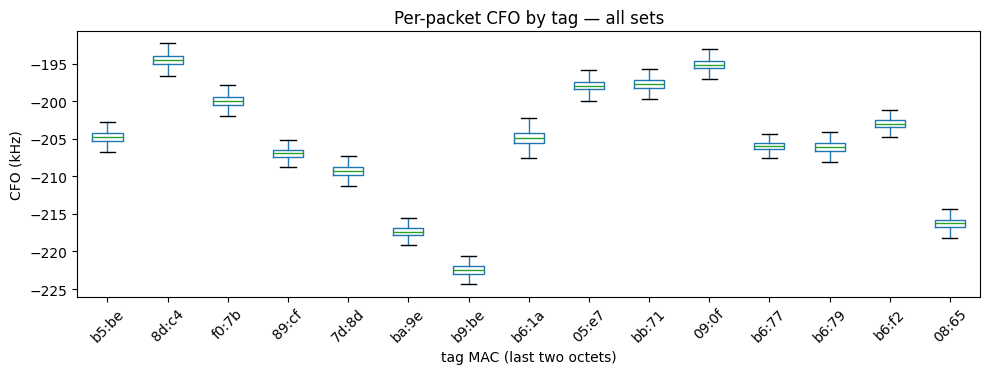

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
order = df.groupby('address')['cfo_kHz'].median().sort_values().index
df.boxplot(column='cfo_kHz', by='address', ax=ax, positions=range(len(order)),
           showfliers=False, grid=False)
ax.set_xticks(range(len(order))); ax.set_xticklabels([a[-5:] for a in order], rotation=45)
ax.set_xlabel('tag MAC (last two octets)'); ax.set_ylabel('CFO (kHz)')
ax.set_title('Per-packet CFO by tag — all sets'); plt.suptitle('')
plt.tight_layout(); plt.show()

### CFO vs. channel

The crystal offset scales with carrier frequency (ppm × f_c), so a small linear trend
across channels is expected for each tag; a large channel-to-channel jump is not.

In [11]:
ch = df.groupby(['address', 'channel'])['cfo_kHz'].median().unstack('channel')
ch.index = [a[-5:] for a in ch.index]
ch.round(1)

channel,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
05:e7,-205.3,-205.3,-205.2,-205.2,-205.1,-205.2,-205.3,-205.2,-204.9,-205.1,...,-204.2,-204.2,-204.3,-204.5,-204.5,-204.6,-204.7,-204.3,-204.5,-204.4
08:65,-195.5,-195.3,-195.4,-195.4,-195.2,-195.2,-195.3,-195.2,-195.0,-195.0,...,-194.0,-194.0,-194.0,-194.1,-193.9,-193.9,-193.9,-193.8,-193.8,-193.9
09:0f,-200.3,-200.5,-200.9,-200.7,-200.8,-200.6,-200.6,-200.5,-200.4,-200.3,...,-199.5,-199.5,-199.5,-199.4,-199.4,-199.3,-199.4,-199.2,-199.4,-199.2
7d:8d,-207.6,-207.5,-207.6,-207.4,-207.5,-207.3,-207.4,-207.2,-207.2,-207.3,...,-206.5,-206.5,-206.5,-206.6,-206.4,-206.6,-206.5,-206.3,-206.5,-206.5
89:cf,-209.6,-209.7,-209.6,-209.7,-209.8,-209.6,-209.6,-209.6,-209.4,-209.5,...,-208.8,-208.6,-208.5,-208.8,-208.7,-208.8,-208.8,-208.8,-209.0,-208.8
8d:c4,-218.0,-217.9,-217.8,-217.8,-217.8,-217.6,-217.8,-217.6,-217.6,-217.6,...,-217.1,-217.1,-216.9,-217.1,-216.9,-217.0,-217.1,-216.9,-217.0,-217.1
b5:be,-222.9,-222.8,-222.8,-222.8,-222.9,-222.9,-222.8,-222.7,-222.7,-222.8,...,-222.1,-222.1,-221.9,-222.1,-222.0,-222.1,-222.3,-222.2,-222.3,-222.4
b6:1a,-206.3,-206.6,-206.3,-205.9,-205.6,-205.6,-205.4,-205.4,-205.2,-205.3,...,-204.1,-204.2,-204.0,-204.1,-203.7,-203.7,-203.8,-203.6,-203.7,-203.7
b6:77,-198.7,-198.6,-198.6,-198.5,-198.6,-198.4,-198.6,-198.3,-198.3,-198.5,...,-197.6,-197.4,-197.4,-197.4,-197.2,-197.2,-197.3,-197.1,-197.3,-197.2
b6:79,-198.4,-198.4,-198.2,-198.4,-198.4,-198.4,-198.3,-198.1,-198.1,-198.0,...,-197.3,-197.0,-197.1,-197.2,-197.0,-197.0,-197.1,-197.0,-197.0,-196.9


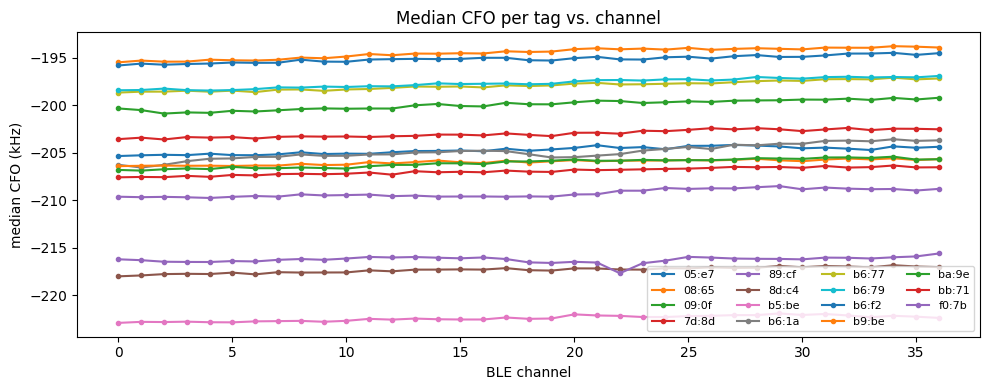

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
for mac, row in ch.iterrows():
    ax.plot(row.index, row.values, '.-', label=mac)
ax.set_xlabel('BLE channel'); ax.set_ylabel('median CFO (kHz)')
ax.set_title('Median CFO per tag vs. channel'); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

## 4. Save

Keep the per-packet CFO next to the raw data so the next step (SFO correction of IQ9–82 and snapshot extraction) does not recompute it.

In [13]:
out = df[['set', 'pt', 'address', 'sequence', 'channel', 'rssi', 'timestamp', 'cfo_kHz', 'cfo_gamma']]
out.to_csv('dataset19_cfo.csv', index=False)
gt.to_csv('dataset19_ground_truth.csv')
print('wrote dataset19_cfo.csv and dataset19_ground_truth.csv')

wrote dataset19_cfo.csv and dataset19_ground_truth.csv


## Summary

- Dataset unzipped; `setup.txt` parsed: 7×7 grid, G = 40 cm, d = 295 cm; 11 fixed reference tags, 4 tracking tags moved between the seven sets.
- 8 CSVs loaded (`set1–set7`, `test`), every MAC matched to a grid point per set.
- Per-packet CFO estimated from the ANT1 reference period (IQ1–IQ8) with a circular mean; `cfo_gamma` flags bad reference periods.
- CFO is per device: it clusters by MAC and is nearly flat across channels.

**Next:** use $\rho$ to de-rotate IQ9–IQ82 (SFO correction), then build 16-antenna snapshots and run the four-way sign test before MUSIC.